# MCDI505 — Análisis de Series de Tiempo
## Formativa 1 — Caso «Bodegaje y quiebres de stock»

| | |
|---|---|
| **Estudiante** | Claudio Rodolfo Alarcón Pradenas |
| **Programa** | Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello |
| **Docente** | Dr. Harvey Jezlid Rosas Quintero |
| **Evaluación** | Formativa 1 · Semana 1 |
| **Fecha** | 2 de octubre de 2026 |
| **Datos** | Demanda semanal simulada de los productos A y B (caso docente de la Sesión 1) |

## 1. Introducción y contexto del dataset

La Gerencia Comercial afirma que la demanda de los productos A y B crece, porque la recta ajustada a cada serie tiene pendiente significativa (p < 0,05), y propone aumentar su inventario en 20 %. El objetivo de este informe es identificar la tendencia, la estacionalidad, el ciclo y el error de cada serie, junto con su dependencia temporal (ACF/PACF), y evaluar si esa evidencia respalda la propuesta.

Las series son simuladas por la función `series_del_caso()` del notebook docente (Universidad Andrés Bello, s.f.): 130 semanas por producto, en unidades demandadas por semana. Se conservan el generador y su semilla, y sus parámetros no se usan como evidencia. El análisis se realiza en Python con `statsmodels` (Seabold y Perktold, 2010).

## 2. Preparación y validación de los datos

In [1]:
# --- Bibliotecas ---
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL

# Las advertencias no se silencian; las del ajuste ARIMA se registran e informan en su tabla.

# --- Reproducibilidad (configuración del notebook docente) ---
SEMILLA = 505
rng = np.random.default_rng(SEMILLA)   # el caso usa su propia semilla (2015) dentro de series_del_caso()

# --- Estilo de los gráficos ---
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 11})
COLORES = {"Producto A": "#b30338", "Producto B": "#0057b8"}
UNIDAD = "unidades/semana"


def fmt_p(p):
    """Formato de valores-p: umbral para valores muy pequeños, en lugar de 0.0000."""
    return "p < 0.001" if p < 0.001 else f"p = {p:.4f}"

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"statsmodels {statsmodels.__version__}")

Python 3.13.16 | numpy 2.5.3 | pandas 3.0.5 | statsmodels 0.15.0


In [2]:
# --- Generación de las series del caso (código docente original, sin modificaciones) ---
def ar1(phi, n, sigma=1.0, m=1, rng=rng):
    """AR(1): X_t = phi * X_{t-1} + e_t, inicializado en su distribución estacionaria si |phi| < 1."""
    e = rng.normal(0.0, sigma, size=(m, n))
    x = np.empty((m, n))
    x[:, 0] = e[:, 0] / np.sqrt(1 - phi**2) if abs(phi) < 1 else 0.0
    for t in range(1, n):
        x[:, t] = phi * x[:, t - 1] + e[:, t]
    return x


def series_del_caso(semilla=2015, n=130):
    g = np.random.default_rng(semilla)
    idx = pd.date_range("2023-01-01", periods=n, freq="W")
    a = 500 + 40 * ar1(0.93, n, m=1, rng=g)[0]                       # producto A
    b = 500 + 0.9 * np.arange(n) + 18 * ar1(0.35, n, m=1, rng=g)[0]  # producto B
    return (pd.Series(a, index=idx, name="Producto A"),
            pd.Series(b, index=idx, name="Producto B"))


prod_a, prod_b = series_del_caso()
productos = {"Producto A": prod_a, "Producto B": prod_b}

# --- Validación de la estructura temporal ---
filas = {}
for nombre, s in productos.items():
    idx = s.index
    filas[nombre] = {
        "observaciones": len(s),
        "inicio": idx.min().date(),
        "fin": idx.max().date(),
        "frecuencia": idx.freqstr,
        "orden cronológico": idx.is_monotonic_increasing,
        "fechas duplicadas": int(idx.duplicated().sum()),
        "valores faltantes": int(s.isna().sum()),
        "sin huecos": idx.equals(pd.date_range(idx.min(), idx.max(), freq=idx.freqstr)),
        "tipo de dato": str(s.dtype),
    }
print(pd.DataFrame(filas).to_string())
print(f"\nCobertura: {len(prod_a)} semanas = {len(prod_a) / 52:.1f} años de 52 semanas")

                   Producto A  Producto B
observaciones             130         130
inicio             2023-01-01  2023-01-01
fin                2025-06-22  2025-06-22
frecuencia              W-SUN       W-SUN
orden cronológico        True        True
fechas duplicadas           0           0
valores faltantes           0           0
sin huecos               True        True
tipo de dato          float64     float64

Cobertura: 130 semanas = 2.5 años de 52 semanas


Las series son semanales (`W-SUN`), van del 1 de enero de 2023 al 22 de junio de 2025 y no tienen duplicados, huecos ni faltantes, por lo que no requieren tratamiento. Cubren unos 2,5 años; 2025 tiene 25 semanas.

## 3. Exploración y visualización

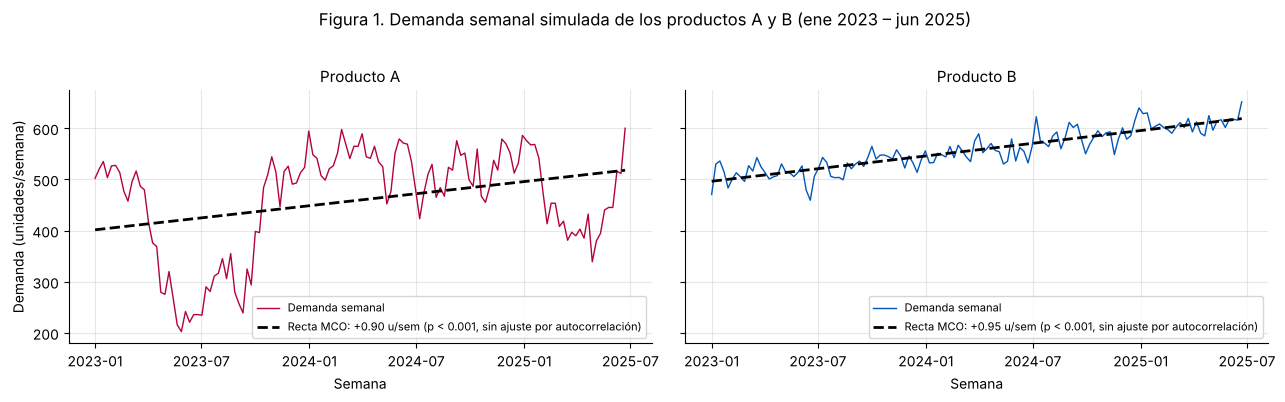

In [3]:
# --- Figura 1: series completas y recta MCO (el procedimiento de la Gerencia) ---
t = np.arange(len(prod_a), dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), sharey=True)
for ax, (nombre, s) in zip(axes, productos.items()):
    ajuste = sm.OLS(s.to_numpy(), sm.add_constant(t)).fit()
    ax.plot(s.index, s, color=COLORES[nombre], lw=1.0, label="Demanda semanal")
    ax.plot(s.index, ajuste.fittedvalues, color="k", lw=2, ls="--",
            label=f"Recta MCO: {ajuste.params[1]:+.2f} u/sem ({fmt_p(ajuste.pvalues[1])}, sin ajuste por autocorrelación)")
    ax.set_title(nombre)
    ax.set_xlabel("Semana")
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel(f"Demanda ({UNIDAD})")
fig.suptitle("Figura 1. Demanda semanal simulada de los productos A y B (ene 2023 – jun 2025)", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# --- Nivel y variabilidad por año calendario ---
# La desviación estándar de los cambios semanales (Δy) separa la variabilidad de corto plazo
# de la variabilidad que proviene de los desplazamientos del nivel.
tablas = []
for nombre, s in productos.items():
    resumen = s.groupby(s.index.year).agg(semanas="size", media="mean", desv_est="std",
                                          minimo="min", maximo="max")
    resumen["desv_est_Δy"] = s.diff().groupby(s.index.year).std()
    resumen.insert(0, "producto", nombre)
    tablas.append(resumen)
por_año = pd.concat(tablas).round(1)
por_año.index.name = "año"
print(por_año.to_string())

for nombre, s in productos.items():
    print(f"\n{nombre}: media {s.mean():.1f} | desv. est. {s.std():.1f} | "
          f"coef. de variación {s.std() / s.mean():.1%} | mín. {s.min():.1f} ({s.idxmin().date()}) | "
          f"máx. {s.max():.1f} ({s.idxmax().date()})")

        producto  semanas  media  desv_est  minimo  maximo  desv_est_Δy
año                                                                    
2023  Producto A       53  395.9     116.9   202.5   594.6         42.4
2024  Producto A       52  527.9      40.9   423.3   597.8         39.4
2025  Producto A       25  453.4      72.3   339.0   600.1         42.2
2023  Producto B       53  521.3      22.0   459.2   564.7         20.4
2024  Producto B       52  569.9      25.6   530.2   639.9         24.1
2025  Producto B       25  609.2      15.1   585.2   651.8         18.2

Producto A: media 459.7 | desv. est. 103.5 | coef. de variación 22.5% | mín. 202.5 (2023-05-28) | máx. 600.1 (2025-06-22)

Producto B: media 557.6 | desv. est. 40.2 | coef. de variación 7.2% | mín. 459.2 (2023-06-18) | máx. 651.8 (2025-06-22)


**¿Crecen las series?** Las rectas MCO tienen pendientes casi iguales (+0,90 y +0,95 u/sem), pero sus valores-p no consideran la autocorrelación (se revisan en la sección 6). **B** crece de forma regular (medias anuales de 521,3; 569,9 y 609,2). **A** no: cae a 202,5 unidades en mayo de 2023, se recupera en 2024 y vuelve a bajar en 2025 (medias de 395,9; 527,9 y 453,4). En A, la recta ascendente puede ser consecuencia de una serie **persistente**, que se mantiene meses sobre o bajo la recta.

**¿Cambia el nivel o la variabilidad?** A presenta desplazamientos de nivel prolongados y es mucho más dispersa (coeficiente de variación de 22,5 %, frente a 7,2 % en B). Su desviación estándar anual varía (116,9; 40,9; 72,3), pero la de los cambios semanales se mantiene cerca de 40, lo que sugiere que esa variación proviene de los desplazamientos de nivel.

**¿Hay estacionalidad o ciclos?** No se aprecia un patrón que se repita en las mismas semanas de cada año, y las oscilaciones de A son pocas e irregulares.

## 4. Descomposición STL

Se utilizó STL (Cleveland et al., 1990) como método formal de descomposición. Como las series son semanales, se fijó un periodo estacional de 52 semanas, con esquema aditivo porque la variabilidad semanal no crece con el nivel. Como la serie contiene cerca de **2,5 ciclos anuales** (2 o 3 observaciones por posición estacional), la componente estacional debe interpretarse con cautela: hay poca repetición para confirmar un patrón estable.

Observaciones por posición estacional: entre 2 y 3
                                     Producto A     Producto B
ventana de tendencia (semanas)              101            101
tendencia: mín. / máx.            345.7 / 535.2  498.4 / 625.6
estacional: mín. / máx.          -184.5 / 186.5   -59.7 / 52.9
semanas con |residuo| < 2 u/sem      105 de 130     115 de 130
advertencias                            ninguna        ninguna


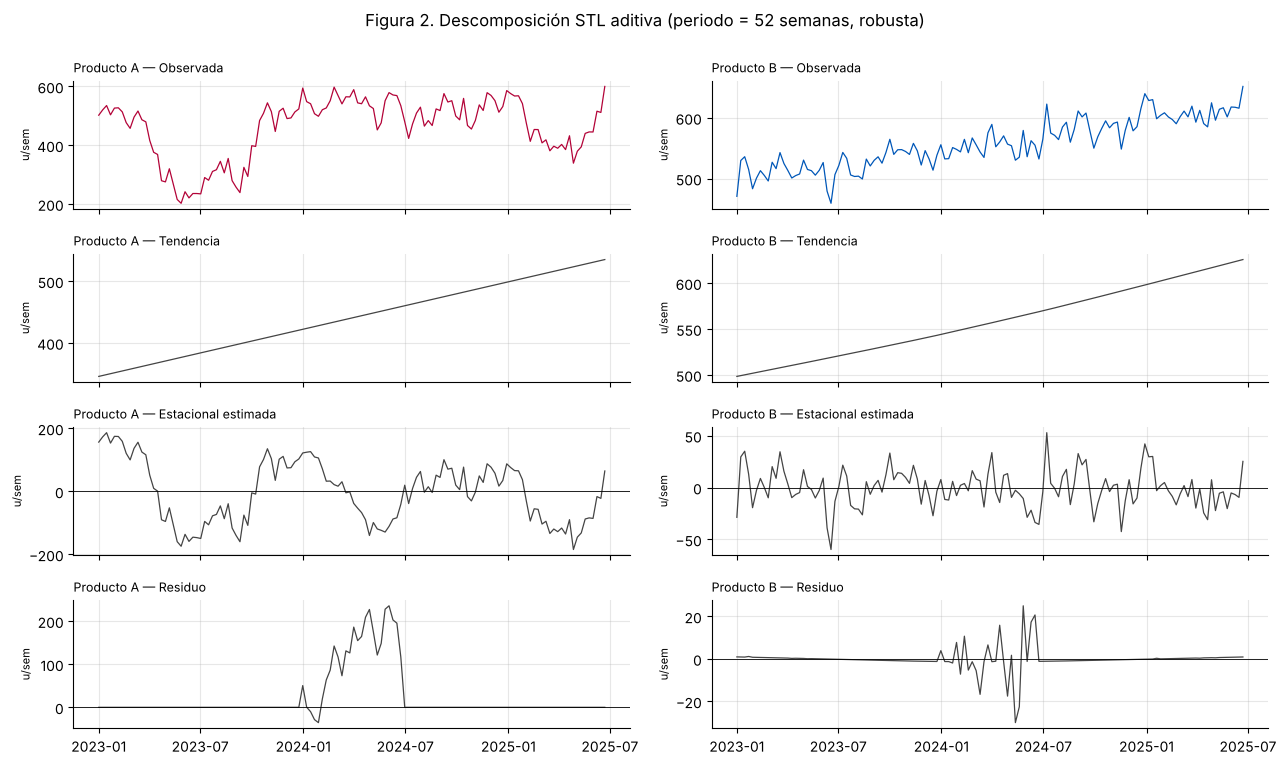

In [5]:
# --- Descomposición STL aditiva (periodo aproximado de 52 semanas) ---
PERIODO = 52
stl_res = {}
filas = {}
for nombre, s in productos.items():
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always")
        modelo_stl = STL(s, period=PERIODO, seasonal=7, robust=True)   # robusta a valores atípicos
        res = modelo_stl.fit()
    stl_res[nombre] = res
    filas[nombre] = {
        "ventana de tendencia (semanas)": modelo_stl.config["trend"],
        "tendencia: mín. / máx.": f"{res.trend.min():.1f} / {res.trend.max():.1f}",
        "estacional: mín. / máx.": f"{res.seasonal.min():.1f} / {res.seasonal.max():.1f}",
        "semanas con |residuo| < 2 u/sem": f"{int((res.resid.abs() < 2).sum())} de {len(s)}",
        "advertencias": "; ".join(str(a.message)[:60] for a in avisos) or "ninguna",
    }
print(f"Observaciones por posición estacional: entre {len(prod_a) // PERIODO} y {-(-len(prod_a) // PERIODO)}")
print(pd.DataFrame(filas).to_string())

fig, axes = plt.subplots(4, 2, figsize=(13, 7.6), sharex=True)
for col, (nombre, res) in enumerate(stl_res.items()):
    for fila, (comp_, titulo) in enumerate([(res.observed, "Observada"), (res.trend, "Tendencia"),
                                            (res.seasonal, "Estacional estimada"), (res.resid, "Residuo")]):
        ax = axes[fila, col]
        ax.plot(comp_.index, comp_, color=COLORES[nombre] if fila == 0 else "#444444", lw=0.9)
        if fila >= 2:
            ax.axhline(0, color="k", lw=0.6)
        ax.set_title(f"{nombre} — {titulo}", fontsize=9, loc="left")
        ax.set_ylabel("u/sem", fontsize=8)
    axes[-1, col].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    axes[-1, col].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.suptitle("Figura 2. Descomposición STL aditiva (periodo = 52 semanas, robusta)", y=1.0)
plt.tight_layout()
plt.show()

Para verificar si el patrón estacional se repite entre años, se calcula como apoyo el residuo respecto de una recta. Ese mismo residuo se usa en la sección 5.

In [6]:
# --- Análisis auxiliar: residuo respecto de una tendencia lineal (MCO) ---
# Sirve para comprobar si el patrón estacional se repite entre años y para el análisis ACF/PACF.
n = len(prod_a)
t = np.arange(n, dtype=float)
resid_lin = {}
filas = {}
for nombre, s in productos.items():
    ajuste = sm.OLS(s.to_numpy(dtype=float), sm.add_constant(t)).fit()
    r = pd.Series(ajuste.resid, index=s.index)
    resid_lin[nombre] = r
    filas[nombre] = {
        "R² de la recta": f"{ajuste.rsquared:.3f}",
        "desv. est. del residuo": f"{r.std():.1f}",
        "ACF(1) del residuo": f"{acf(r, nlags=1)[1]:.3f}",
        "ACF del residuo en rezago 52": f"{acf(r, nlags=52)[52]:.3f}",
        "corr. semanas 1-52 vs 53-104": f"{np.corrcoef(r[:52], r[52:104])[0, 1]:.3f}",
    }
print(pd.DataFrame(filas).to_string())


                             Producto A Producto B
R² de la recta                    0.108      0.793
desv. est. del residuo             97.7       18.3
ACF(1) del residuo                0.906      0.297
ACF del residuo en rezago 52     -0.119     -0.069
corr. semanas 1-52 vs 53-104      0.174     -0.019


**Interpretación de los componentes**

- **Tendencia.** Es casi lineal en ambos productos, porque la ventana STL abarca 101 semanas. En B describe bien la serie: crece de 498,4 a 625,6, y la recta explica el 79,3 % de la variación. En A resume poco una trayectoria de subidas y bajadas: la recta explica solo el 10,8 %.
- **Estacionalidad.** STL estima una componente amplia, pero el patrón no se repite entre años: la correlación entre las semanas 1–52 y 53–104 es de 0,174 en A y de −0,019 en B, y la autocorrelación en el rezago 52 es baja. **No se identificó evidencia suficiente de estacionalidad anual**; con 2,5 ciclos no es posible confirmarla ni descartarla.
- **Ciclo.** Un ciclo es una oscilación de periodo variable, no ligada al calendario (Hyndman y Athanasopoulos, 2021). Las pocas oscilaciones de A no se distinguen de su persistencia, y en B no aparecen, así que el ciclo no es identificable con 130 semanas.
- **Residuo.** El residuo STL resulta muy pequeño en gran parte de ambas series (bajo 2 u/sem en 105 de 130 semanas en A y en 115 en B). Con solo 2,5 ciclos anuales, esto refuerza la cautela con la componente estacional, que puede estar capturando variación que no corresponde a un patrón anual estable. El error se describe mejor con el residuo de la recta: grande y persistente en A (ACF(1) = 0,906), pequeño y con dependencia leve en B (0,297).

## 5. ACF y PACF

Se analizan la serie original y el residuo de la recta con 30 rezagos. Las bandas de la figura y de la tabla son las mismas (Bartlett para la ACF y $\pm 1{,}96/\sqrt{n}$ para la PACF) y deben leerse como referencias aproximadas.

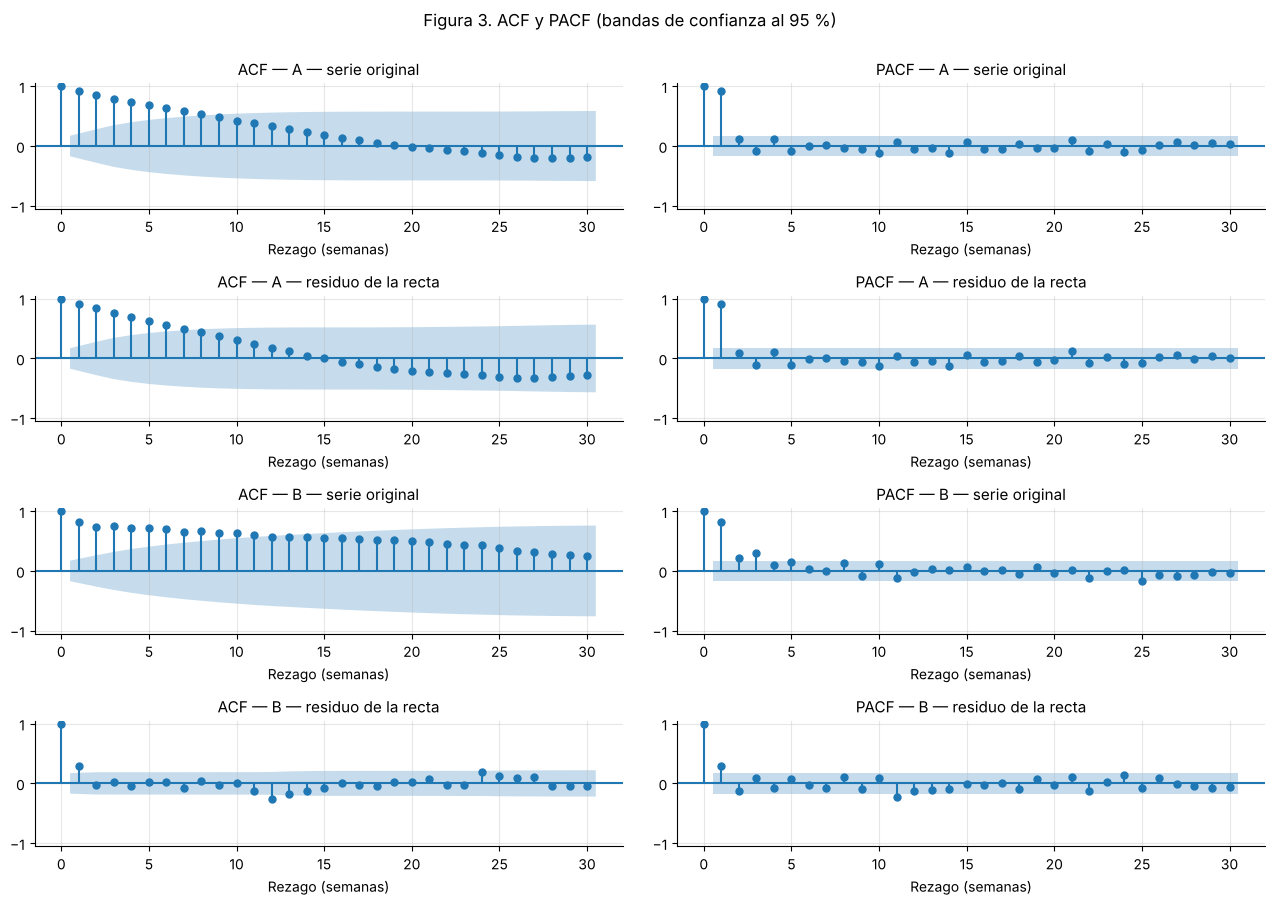

In [7]:
# --- Figura 3: ACF y PACF de cada serie original y de su residuo respecto de la recta ---
N_LAGS = 30   # ≈ n/4 = 32 para n = 130
series_acf = {
    "A — serie original": prod_a,
    "A — residuo de la recta": resid_lin["Producto A"],
    "B — serie original": prod_b,
    "B — residuo de la recta": resid_lin["Producto B"],
}
fig, axes = plt.subplots(4, 2, figsize=(13, 9.0))
for fila, (nombre, s) in enumerate(series_acf.items()):
    plot_acf(s, lags=N_LAGS, alpha=0.05, ax=axes[fila, 0], title=f"ACF — {nombre}")
    plot_pacf(s, lags=N_LAGS, alpha=0.05, method="ywm", ax=axes[fila, 1], title=f"PACF — {nombre}")
    for ax in axes[fila]:
        ax.set_xlabel("Rezago (semanas)")
        ax.set_ylim(-1.05, 1.05)
fig.suptitle("Figura 3. ACF y PACF (bandas de confianza al 95 %)", y=1.0)
plt.tight_layout()
plt.show()

In [8]:
# --- Valores y rezagos fuera de las MISMAS bandas que dibujan los gráficos ---
# ACF: banda de Bartlett, 1,96·√[(1 + 2·Σ_{j<k} r_j²)/n], que se ensancha con el rezago
# (es la que usa plot_acf). PACF: banda ±1,96/√n (la que usa plot_pacf).
for nombre, s in series_acf.items():
    x = np.asarray(s, dtype=float)
    n_s = len(x)
    r = acf(x, nlags=N_LAGS)
    p = pacf(x, nlags=N_LAGS, method="ywm")
    banda_acf = 1.96 * np.sqrt(np.r_[np.nan, 1 + 2 * np.cumsum(np.r_[0, r[1:N_LAGS] ** 2])] / n_s)
    fuera_acf = [k for k in range(1, N_LAGS + 1) if abs(r[k]) > banda_acf[k]]
    fuera_pacf = [k for k in range(1, N_LAGS + 1) if abs(p[k]) > 1.96 / np.sqrt(n_s)]
    print(f"── {nombre}")
    print("   ACF  rezagos 1, 2, 3, 5, 10, 20:", np.round(r[[1, 2, 3, 5, 10, 20]], 3))
    print("   PACF rezagos 1, 2, 3:          ", np.round(p[[1, 2, 3]], 3))
    print("   ACF fuera de banda : ", {k: round(float(r[k]), 3) for k in fuera_acf})
    print("   PACF fuera de banda: ", {k: round(float(p[k]), 3) for k in fuera_pacf})

── A — serie original
   ACF  rezagos 1, 2, 3, 5, 10, 20: [ 0.915  0.856  0.785  0.681  0.427 -0.019]
   PACF rezagos 1, 2, 3:           [ 0.915  0.12  -0.088]
   ACF fuera de banda :  {1: 0.915, 2: 0.856, 3: 0.785, 4: 0.742, 5: 0.681, 6: 0.631, 7: 0.584, 8: 0.539}
   PACF fuera de banda:  {1: 0.915}
── A — residuo de la recta
   ACF  rezagos 1, 2, 3, 5, 10, 20: [ 0.906  0.838  0.754  0.625  0.302 -0.215]
   PACF rezagos 1, 2, 3:           [ 0.906  0.091 -0.105]
   ACF fuera de banda :  {1: 0.906, 2: 0.838, 3: 0.754, 4: 0.7, 5: 0.625, 6: 0.563, 7: 0.5}
   PACF fuera de banda:  {1: 0.906}
── B — serie original
   ACF  rezagos 1, 2, 3, 5, 10, 20: [0.818 0.742 0.747 0.713 0.635 0.495]
   PACF rezagos 1, 2, 3:           [0.818 0.22  0.296]
   ACF fuera de banda :  {1: 0.818, 2: 0.742, 3: 0.747, 4: 0.72, 5: 0.713, 6: 0.694, 7: 0.658, 8: 0.671, 9: 0.633, 10: 0.635, 11: 0.597}
   PACF fuera de banda:  {1: 0.818, 2: 0.22, 3: 0.296, 25: -0.174}
── B — residuo de la recta
   ACF  rezagos 1, 2, 3

**Interpretación**

- **Producto A.** La ACF decae gradualmente (0,915 en el rezago 1; 0,427 en el 10) y la PACF solo destaca en el rezago 1. Hay una dependencia fuerte entre semanas consecutivas que se propaga en el tiempo, compatible con un proceso autorregresivo muy persistente. El patrón casi no cambia en el residuo de la recta (0,906), así que **la persistencia no se debe a la tendencia**.
- **Producto B.** La ACF original decae lentamente (0,818; 0,495 en el rezago 20), un patrón típico de una serie con tendencia. Al quitar la recta cae a 0,297 y luego queda cerca de cero: **la persistencia provenía de la tendencia** y solo resta una dependencia leve de un periodo.
- **Rezagos aislados** (ACF en el 12 y PACF en el 11 del residuo de B). Podrían deberse al azar; como no se repiten en múltiplos, no se interpretan como estacionalidad.
- **Comparación.** Con pendientes casi iguales, la autocorrelación residual ronda 0,9 en A y 0,3 en B, lo que condiciona la validez de los valores-p de la Gerencia.

## 6. Interpretación técnica integrada

MCO supone errores independientes; con residuos autocorrelacionados tiende a subestimar la incertidumbre de la pendiente. Por eso se compara con una regresión con tendencia y errores AR(1), coherente con la PACF de la sección 5.

In [9]:
# --- Contraste de la pendiente: MCO (procedimiento de la Gerencia) vs. tendencia con errores AR(1) ---
filas = {}
for nombre, s in productos.items():
    y = s.to_numpy(dtype=float)
    mco = sm.OLS(y, sm.add_constant(t)).fit()                      # supone errores independientes
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always")
        ar1_t = ARIMA(y, order=(1, 0, 0), trend="ct").fit()        # incorpora la dependencia de rezago 1
    filas[nombre] = {
        "MCO: pendiente (u/sem)": f"{mco.params[1]:+.3f} ({fmt_p(mco.pvalues[1])})",
        "tendencia + AR(1): pendiente": f"{ar1_t.params[1]:+.3f} ({fmt_p(ar1_t.pvalues[1])})",
        "φ̂ del AR(1)": f"{ar1_t.params[2]:.3f}",
        "convergencia / advertencias": f"{ar1_t.mle_retvals.get('converged')} / "
                                       + ("; ".join(str(a.message)[:50] for a in avisos) or "ninguna"),
        "crecimiento en 13 sem (% nivel reciente)": f"{100 * 13 * mco.params[1] / y[-13:].mean():+.1f} %",
    }
print(pd.DataFrame(filas).to_string())

                                                   Producto A          Producto B
MCO: pendiente (u/sem)                     +0.903 (p < 0.001)  +0.949 (p < 0.001)
tendencia + AR(1): pendiente              +0.851 (p = 0.3350)  +0.959 (p < 0.001)
φ̂ del AR(1)                                            0.912               0.307
convergencia / advertencias                    True / ninguna      True / ninguna
crecimiento en 13 sem (% nivel reciente)               +2.7 %              +2.0 %


- **A.** Al incorporar la dependencia, la pendiente deja de ser significativa (p = 0,335; φ̂ = 0,912). Con los datos disponibles, **la evidencia de una tendencia lineal creciente no resulta concluyente una vez considerada la dependencia temporal**. Esto no demuestra que no exista tendencia.
- **B.** La pendiente se mantiene (+0,959; p < 0,001; φ̂ = 0,307): **la evidencia de una tendencia lineal creciente se mantiene consistente al considerar la dependencia temporal**.

Ambos ajustes convergieron sin advertencias.

| | Producto A | Producto B |
|---|---|---|
| Tendencia | No concluyente al considerar la dependencia | Lineal creciente (≈ +0,95 u/sem), consistente al considerar la dependencia |
| Estacionalidad | No identificada (STL no validable con 2,5 ciclos) | No identificada |
| Ciclo | No identificable | No identificable |
| Error / dependencia | Persistencia fuerte (ACF(1) del residuo = 0,906) | Dependencia leve (0,297) |

**Inventario.** En ambos productos la pendiente equivale a un crecimiento de 2–3 % del nivel reciente en un trimestre (comparación solo ilustrativa con el 20 %). Una tendencia creciente en la demanda no implica por sí sola aumentar el inventario: esa decisión requiere considerar además *lead time*, nivel de servicio, incertidumbre, costos y política de reposición.

## 7. Conclusiones

Las dos series tienen pendientes MCO similares, pero estructuras temporales distintas.

**Producto A.** Está dominado por la persistencia. Con los datos disponibles, la evidencia de una tendencia lineal creciente no resulta concluyente una vez considerada la dependencia temporal. **Producto B.** Presenta una tendencia lineal creciente que se mantiene al considerar la dependencia, con una dependencia residual leve. En ninguno se identifican estacionalidad ni ciclos.

**Decisión.** La evidencia de la Gerencia no justifica por sí sola aumentar el inventario en 20 % en ninguno de los dos productos. El valor-p de MCO no es una base adecuada con residuos autocorrelacionados, y el crecimiento de B no basta para derivar esa cifra.

**Modelamiento posterior y limitaciones.** A requerirá un modelo que represente la persistencia (por ejemplo, autorregresivo) y una evaluación de posible raíz unitaria. Para B son candidatos una tendencia con errores AR(1) o un ARIMA con deriva. Limitaciones: datos simulados, solo 2,5 años (insuficientes para validar la estacionalidad), tendencia lineal supuesta y bandas ACF/PACF aproximadas.

## Referencias

Cleveland, R. B., Cleveland, W. S., McRae, J. E., y Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics, 6*(1), 3–73.

Hyndman, R. J., y Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3.ª ed.). OTexts. https://otexts.com/fpp3/

Seabold, S., y Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. En S. van der Walt y J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011

Universidad Andrés Bello. (s.f.). *MCDI505 — Sesión 1: Naturaleza de los datos temporales y autocorrelación* [Notebook de Jupyter, material docente del curso].

---
**Declaración de uso de IA.** Se utilizó inteligencia artificial generativa únicamente como apoyo para organizar ideas y mejorar la redacción del informe. Los resultados y conclusiones fueron revisados a partir de la ejecución del notebook.